# Ensemble Strategy: Combine MR and MOM to Improve Performance

It's commonly known that MR (Mean Reversion) performs well in ranging markets, while MOM (Momentum) tends to excel in trending markets. By combining these two strategies, we can create a more robust trading approach that adapts to different market conditions.

From MR strategy exercise (at `notebooks/mean_reversion_strategy.ipynb`), we found that EBAY and AVGO are cointegrated pairs, so we'll trade AVGO stock using the MR and MOM strategies combined. The idea is to use the MR strategy when the market is ranging and switch to the MOM strategy when the market is trending.

In [1]:
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

In [2]:
STOCK = "AVGO"
MR_PAIR = "EBAY"
WINDOW = {
  "start": "2022-10-01",
  "end": "2026-09-01"
}
TRAIN_WINDOW = {
  "start": "2022-10-01",
  "end": "2025-09-30"
}
TEST_WINDOW = {
  "start": "2025-10-01",
  "end": "2026-09-01"
}
TRAIN_RANGE = slice("2022-10-01", "2025-09-30")
TEST_RANGE = slice("2025-10-01", "2026-09-01")

In [3]:
# Corresponds to s2 in mean_reversion_strategy.ipynb
stock = yf.Ticker(STOCK).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
spy = yf.Ticker("SPY").history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
stock.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,42.440652,43.546922,42.226199,43.152973,21479000,0.0,0.0
2022-10-04 00:00:00-04:00,44.260185,45.361730,44.010778,45.333389,27277000,0.0,0.0
2022-10-05 00:00:00-04:00,44.642790,46.110884,44.539814,45.800072,18493000,0.0,0.0
2022-10-06 00:00:00-04:00,45.704664,46.262993,45.225690,45.299377,17250000,0.0,0.0
2022-10-07 00:00:00-04:00,44.626727,44.717421,43.364581,43.502510,28425000,0.0,0.0


In [4]:
# Corresponds to s1 in mean_reversion_strategy.ipynb
mr_pair = yf.Ticker(MR_PAIR).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
mr_pair.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,34.381840,35.014749,33.674473,34.642452,8930300,0.0,0.0
2022-10-04 00:00:00-04:00,35.470814,36.466715,35.452199,35.992031,8189800,0.0,0.0
2022-10-05 00:00:00-04:00,35.601127,36.755257,35.535975,36.410877,7290500,0.0,0.0
2022-10-06 00:00:00-04:00,36.252646,36.885556,36.150264,36.196800,6471800,0.0,0.0
2022-10-07 00:00:00-04:00,35.843118,35.908273,34.828602,34.949600,6731600,0.0,0.0


## Mean Reversion (MR) Strategy

In [5]:
X = sm.add_constant(mr_pair[TRAIN_RANGE]['Close'])
y = stock[TRAIN_RANGE]['Close']
model = sm.OLS(y, X).fit()

hedge_ratio = model.params['Close']
intercept = model.params['const']

print(f"Intercept: {intercept:.4f}")
print(f"Hedge Ratio: {hedge_ratio:.4f}")

Intercept: -118.6631
Hedge Ratio: 4.8536


In [6]:
spread = stock['Close'] - hedge_ratio * mr_pair['Close']
spread_mean = spread[TRAIN_RANGE].mean()
spread_std = spread[TRAIN_RANGE].std()

print(f"Spread Mean: {spread_mean:.4f}")
print(f"Spread Std Dev: {spread_std:.4f}")

Spread Mean: -118.6631
Spread Std Dev: 24.3706


## Momentum (MR) Strategy

For MR strategy, we'll use SMA crossover on AVGO.

In [7]:
# Hyperparameters
short_n = 20
long_n = 60

In [8]:
# Compute SMAs
sma_short = stock['Close'].rolling(short_n).mean()
sma_long = stock['Close'].rolling(long_n).mean()

# Combine: Ensemble of MR and MOM

We'll combine the MR and MOM strategies based on the market condition using ADX. If ADX tells us that the market is trending, we'll weight more on the MOM strategy, and if ADX indicates a ranging market, we'll weight more on the MR strategy. The final position will be a weighted average of the two strategies.

So the trading logic is as follows:

### General Rules

- **No position (Flat)**:
  - If $S_{combined} \ge \theta_{entry}$, enter a long position (Position = 1)
  - If $S_{combined} \le -\theta_{entry}$, enter a short position (Position = -1)
- **Long position (Position = 1)**:
  - Exit when $S_{combined} \le \theta_{exit}$
- **Short position (Position = -1)**:
  - Exit when $S_{combined} \ge -\theta_{exit}$

### Signal Definition

$$
S_{combined} = w_{MR} * S_{MR} + w_{MOM} * S_{MOM}
$$

where:

- $w_{MR} + w_{MOM} = 1$
- $w_{MOM} = \sigma(k(ADX - \tau))$
  - $\sigma = \frac{1}{1 + e^{-x}}$ (Sigmoid function)
  - $k \in [0, 1]$
  - $\tau$ is the threshold for ADX to determine if the market is trending or ranging.

#### Signal Component - Mean Reversion (MR)

We'll format each signal component as a z-score to ensure they are on the same scale. So the MR signal will be defined as:

$$
S_{MR} = - \frac{Spread - \mu_{Spread}}{\sigma_{Spread}}
$$

#### Signal Component - Momentum (MOM)

As for the MOM signal, we'll use the SMA crossover strategy. The MOM signal will be defined as:

$$
S_{MOM} = \frac{D(t) - \mu_{D(t)}}{\sigma_{D(t)}}
$$

where:
- $D(t) = SMA_{short}(t) - SMA_{long}(t)$
- $\mu_{D(t)}$ and $\sigma_{D(t)}$ are the mean and standard deviation of $D(t)$, respectively.

In [9]:
# Hyperparameters
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade (commission + slippage)
theta_entry = 2.0
theta_exit = 0.0
k = 0.15 # Try [0.15, 0.20, 0.40]
tau = 30 # Try [20, 25, 30]

In [10]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

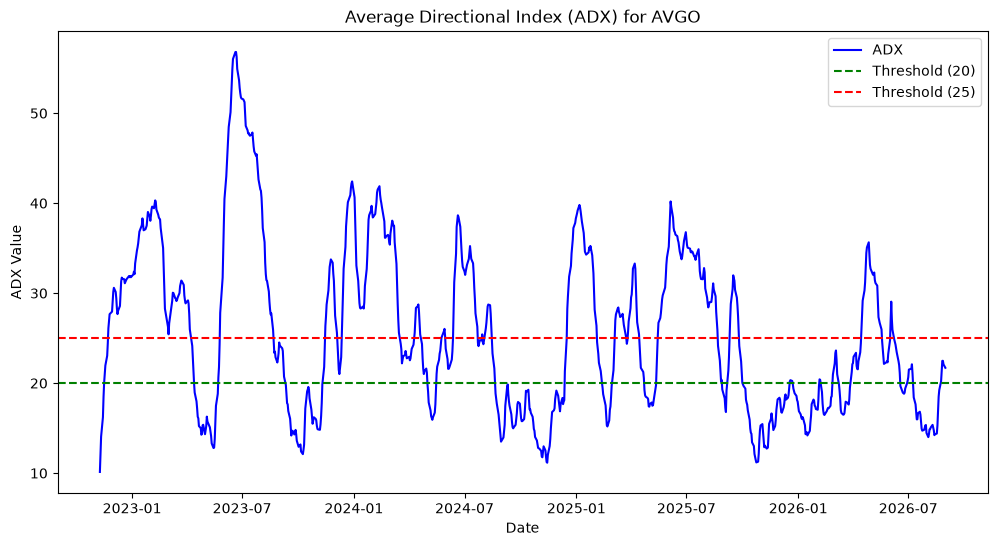

In [11]:
adx = talib.ADX(stock['High'], stock['Low'], stock['Close'], timeperiod=14)

plt.figure(figsize=(12, 6))
plt.plot(adx, label='ADX', color='blue')
plt.axhline(y=20, color='green', linestyle='--', label='Threshold (20)')
plt.axhline(y=25, color='red', linestyle='--', label='Threshold (25)')
plt.title(f'Average Directional Index (ADX) for {STOCK}')
plt.xlabel('Date')
plt.ylabel('ADX Value')
plt.legend()

In [12]:
# Construct S_combined
w_mom = round(sigmoid(k * (adx - tau)) * 5) / 5
w_mr = 1 - w_mom

s_mr = -1 * ((spread - spread_mean) / spread_std)

d_t = sma_short - sma_long
d_t_mean = d_t[TRAIN_RANGE].mean()
d_t_std = d_t[TRAIN_RANGE].std()
s_mom = (d_t - d_t_mean) / d_t_std

s_combined = w_mr * s_mr + w_mom * s_mom

s_combined = s_combined.to_frame(name='S_combined')
s_combined.tail()

,S_combined
Date,
2026-08-25 00:00:00-04:00,1.138600
2026-08-26 00:00:00-04:00,0.905995
2026-08-27 00:00:00-04:00,0.091645
2026-08-28 00:00:00-04:00,0.777676
2026-08-31 00:00:00-04:00,0.393931


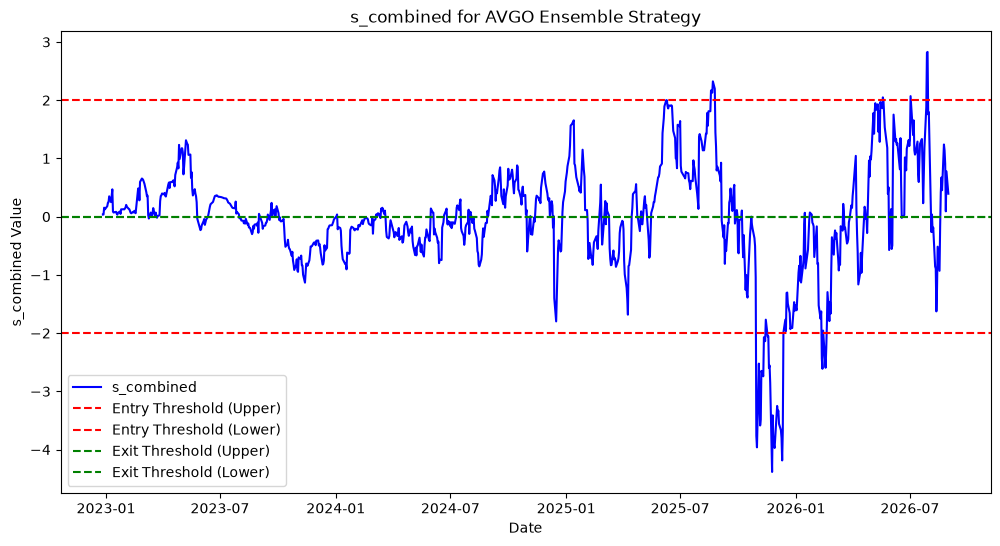

In [13]:
# Plot s_combined
plt.figure(figsize=(12, 6))
plt.plot(s_combined, label='s_combined', color='blue')
plt.axhline(y=theta_entry, color='red', linestyle='--', label='Entry Threshold (Upper)')
plt.axhline(y=-theta_entry, color='red', linestyle='--', label='Entry Threshold (Lower)')
plt.axhline(y=theta_exit, color='green', linestyle='--', label='Exit Threshold (Upper)')
plt.axhline(y=-theta_exit, color='green', linestyle='--', label='Exit Threshold (Lower)')
plt.title(f's_combined for {STOCK} Ensemble Strategy')
plt.xlabel('Date')
plt.ylabel('s_combined Value')
plt.legend()
plt.show()

In [14]:
# Determine entry and exit signals
positions = pd.DataFrame(index=stock.index)
positions['position'] = 0

current_pos = 0
prev_pos = 0
for i in positions.index:
    s = s_combined.loc[i, 'S_combined']

    prev_pos = current_pos

    def set_position(i, pos):
        positions.loc[i, 'position'] = pos

    if prev_pos == 0:
        if s >= theta_entry:
            current_pos = 1 # Long
            set_position(i, current_pos)
            continue
        if s <= -theta_entry:
            current_pos = 1  # Short
            set_position(i, current_pos)
            continue
        current_pos = 0  # No position
        set_position(i, current_pos)
        continue

    if prev_pos == 1:
        if s <= theta_exit:
            current_pos = 0  # Exit long
            set_position(i, current_pos)
            continue
        current_pos = 1  # Maintain long
        set_position(i, current_pos)
        continue

    if prev_pos == -1:
        if s >= -theta_exit:
            current_pos = 0  # Exit short
            set_position(i, current_pos)
            continue
        current_pos = -1  # Maintain short
        set_position(i, current_pos)
        continue

    raise ValueError(f"Unexpected position: {prev_pos}")
    
positions.head()

,position
Date,
2022-10-03 00:00:00-04:00,0
2022-10-04 00:00:00-04:00,0
2022-10-05 00:00:00-04:00,0
2022-10-06 00:00:00-04:00,0
2022-10-07 00:00:00-04:00,0


## Backtesting

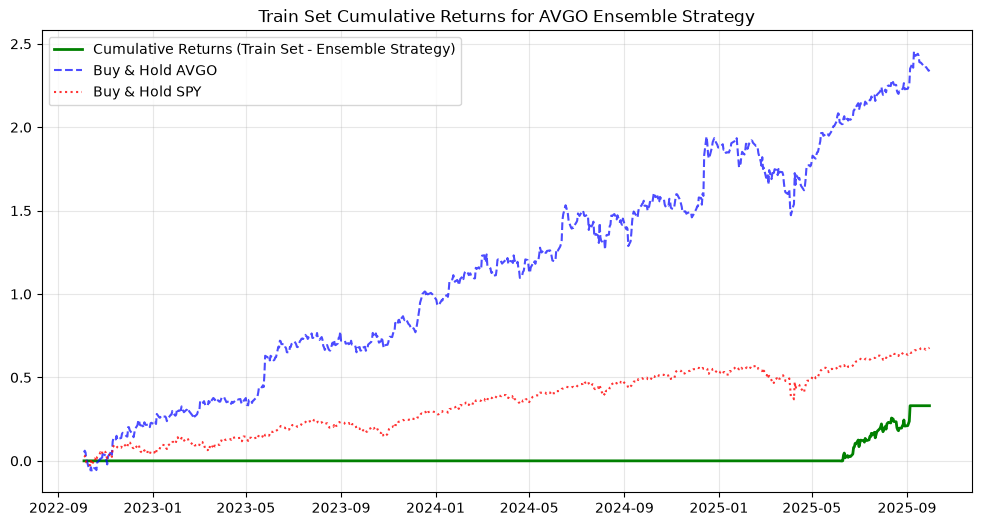

In [15]:
# Compute portfolio returns
portfolio_return = pd.DataFrame(index=stock.index)
portfolio_return['gross_return'] = positions['position'].shift(1) * stock['Close'].pct_change()
portfolio_return['trades'] = positions['position'].diff().fillna(0).abs()
portfolio_return['transaction_costs'] = portfolio_return['trades'] * TRANSACTION_COST_RATE
portfolio_return['net_return'] = portfolio_return['gross_return'] - portfolio_return['transaction_costs']

# Calculate profit and loss (PnL)
pnl_train = portfolio_return[TRAIN_RANGE]['net_return'].cumsum()
bh_stock_train = stock['Close'].pct_change()[TRAIN_RANGE].cumsum()
bh_spy_train = spy['Close'].pct_change()[TRAIN_RANGE].cumsum()

# Plot the cumulative PnL
plt.figure(figsize=(12, 6))
plt.plot(pnl_train, label='Cumulative Returns (Train Set - Ensemble Strategy)', color='green', linewidth=2)
plt.plot(bh_stock_train, label=f'Buy & Hold {STOCK}', color='blue', linestyle='--', alpha=0.7)
plt.plot(bh_spy_train, label='Buy & Hold SPY', color='red', linestyle=':', alpha=0.8)
plt.title(f'Train Set Cumulative Returns for {STOCK} Ensemble Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
r_train = portfolio_return['net_return'][TRAIN_RANGE]
sharpe_train = r_train.mean() / r_train.std() * np.sqrt(252)  # Annualized Sharpe ratio
print(f"Train Set Sharpe Ratio: {sharpe_train:.4f}")

mdd_train = (pnl_train.cummax() - pnl_train).max()
drawdown_trough_train = (pnl_train.cummax() - pnl_train).idxmax()
drawdown_peak_train = pnl_train[:drawdown_trough_train].idxmax()
mdd_duration_train = drawdown_trough_train - drawdown_peak_train
print(f"Train Set Maximum Drawdown: {mdd_train:.4f}")
print(f"Train Set Maximum Drawdown Duration: {mdd_duration_train.days} days")

Train Set Sharpe Ratio: 1.1148
Train Set Maximum Drawdown: 0.0762
Train Set Maximum Drawdown Duration: 9 days


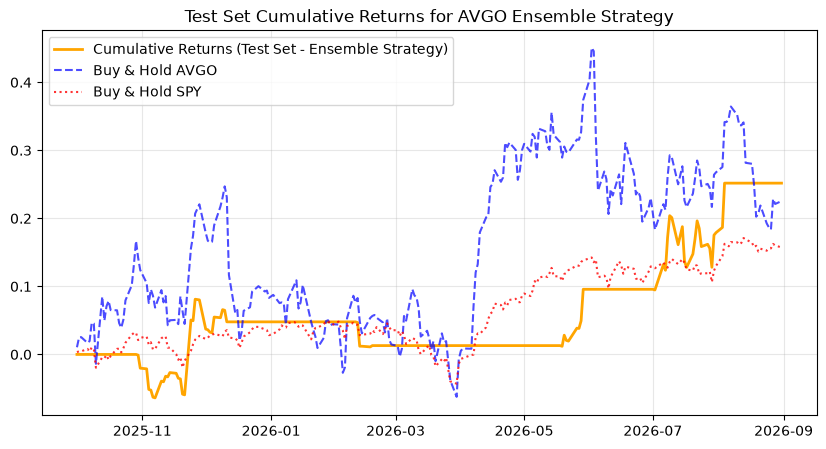

In [17]:
pnl_test = portfolio_return['net_return'][TEST_RANGE].cumsum()
bh_stock_test = stock['Close'].pct_change()[TEST_RANGE].cumsum()
bh_spy_test = spy['Close'].pct_change()[TEST_RANGE].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(pnl_test, label='Cumulative Returns (Test Set - Ensemble Strategy)', color='orange', linewidth=2)
plt.plot(bh_stock_test, label=f'Buy & Hold {STOCK}', color='blue', linestyle='--', alpha=0.7)
plt.plot(bh_spy_test, label='Buy & Hold SPY', color='red', linestyle=':', alpha=0.8)
plt.title(f'Test Set Cumulative Returns for {STOCK} Ensemble Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
r_test = portfolio_return['net_return'][TEST_RANGE]
sharpe_test = r_test.mean() / (r_test.std() + 1e-12) * np.sqrt(252)
print(f"Test Set Sharpe Ratio: {sharpe_test:.4f}")

mdd_test = (pnl_test.cummax() - pnl_test).max()
drawdown_trough_test = (pnl_test.cummax() - pnl_test).idxmax()
drawdown_peak_test = pnl_test[:drawdown_trough_test].idxmax()
mdd_duration_test = drawdown_trough_test - drawdown_peak_test
print(f"Test Set Maximum Drawdown: {mdd_test:.4f}")
print(f"Test Set Maximum Drawdown Duration: {mdd_duration_test.days} days")

Test Set Sharpe Ratio: 1.2883
Test Set Maximum Drawdown: 0.0761
Test Set Maximum Drawdown Duration: 8 days
